# Closure Certificate vs a Strong 4-Signal Confidence-Thresholded Neural Abstainer

**Demo of:** *"No Derivation, No Relation"* — STEP A re-analysis.

**The question.** When a short story gives **no derivation path** between two people
(they live in disconnected halves of the kinship graph), the gold answer is
`no-relation`. A raw LLM nonetheless **confidently invents** a kinship on ~47% of such
pairs. Is that hallucination something an *uncertainty signal the LLM already has* could
catch — or does it take a **structural closure certificate** (no path ⇒ abstain)?

We pit the certificate against the **best available confidence/uncertainty battery** —
not a weak strawman — at **matched coverage**:

| signal | definition |
|---|---|
| **verbalized** | the answerer's self-reported confidence in [0,1] |
| **sc_margin** | self-consistency vote-margin over k=10 temp-0.7 samples |
| **ptrue** | Kadavath **P(True)**: the model's probability its own answer is correct |
| **negent** | semantic-entropy negentropy over the k=10 samples |

Each signal defines a confidence-thresholded RAW-ABSTAIN baseline `ct_<signal>`.

**This demo** loads a curated 100-row subset of the published CLUTRR *absent-relation*
pool (per-query predictions + the four signal values already collected with
`google/gemini-3.1-flash-lite`) and re-runs the **load-bearing statistical analysis
verbatim** — no LLM calls. It reproduces the headline:

* the raw LLM hallucinates a kinship on ~47% of absent pairs; the certificate's
  confident-wrong rate is near 0 (**~0.44 reduction**, bootstrap CI excludes 0);
* the **crux**: of the LLM's high-confidence hallucinations, a confidence rule calibrated
  to the certificate's coverage still **lets ~25–72% through** — confidence cannot *see*
  absent-relation hallucinations, but the closure certificate abstains on all of them.

> The original `method.py` is an orchestrator whose Stages 1–3 issue (cached) OpenRouter
> LLM calls to build the per-query records. This notebook **replaces only that
> data-acquisition front-end** with loading the already-computed predictions, then runs
> the **verbatim** Stage-4/5 analysis (`baselines.absent_h2`, `method.crux_survival_table`,
> `stats.matched_coverage_mask` / `stats.holm_bonferroni`).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

# numpy + matplotlib are pre-installed on Colab -> install locally only (at Colab versions)
if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "matplotlib==3.10.0")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- imports (from method.py), plus matplotlib for the demo visualization ---
import json
import math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-6/experiment-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("dataset:", data["dataset"])
print("n examples:", len(data["examples"]))
print("signals:", data["signals"])
print()
print("full-pool published headline (for end-of-notebook comparison):")
for k, v in data["reference_headline_full_pool"].items():
    print(f"  {k}: {v}")

dataset: clutrr_no_derivation
n examples: 100
signals: ['verbalized', 'sc_margin', 'ptrue', 'negent']

full-pool published headline (for end-of-notebook comparison):
  full_pool_n_absent: 180
  raw_llm_absent_hallucination_rate: 0.4722
  certificate_absent_confident_wrong: 0.0278
  absent_confident_wrong_reduction_vs_raw: 0.4444
  absent_reduction_ci95: [0.3167, 0.5833]
  crux_frac_absent_hallucinations_surviving_each_signal: {'ct_verbalized': 0.4353, 'ct_sc_margin': 0.7176, 'ct_ptrue': 0.2471, 'ct_negent': 0.7176}


## Config

All tunable parameters live here. They start at the demo minimum; scale back toward the
original full-run values (shown in comments) for a faithful reproduction.

In [5]:
# ============================ CONFIG ============================
SIGNALS = ("verbalized", "sc_margin", "ptrue", "negent")  # the 4-signal battery
SEED = 20260617                                            # original method.py SEED

# Story-clustered paired bootstrap replicates.
#   demo (fast)                         : B_BOOT = 2000
#   baselines.absent_h2 original default: 2000
#   method.py mixed-pool headline B_BOOT: 10000
B_BOOT = 2000

# How many absent-pool rows to analyse (the mini file holds 100).
#   original full no-derivation pool: 180
DEMO_LIMIT = 100

## Scoring primitives (verbatim from `stats.py` + `baselines.py`)

These are the exact functions the experiment uses. `matched_coverage_mask` thresholds any
method to a target coverage by ranking on its confidence; `confident_wrong` is the central
metric (on an absent pair, *any* named answer is wrong); `coverage_confidence` makes an
abstention never count as "covered"; `holm_bonferroni` does the step-down multiplicity
adjustment across the 4 signals.

In [6]:
# --- verbatim from stats.py ---
def matched_coverage_mask(conf: np.ndarray, target_cov: float) -> np.ndarray:
    """Boolean mask covering the top ceil(target_cov * N) items by confidence (ties by index)."""
    n = len(conf)
    k = int(round(target_cov * n))
    k = max(0, min(n, k))
    mask = np.zeros(n, dtype=bool)
    if k == 0:
        return mask
    order = sorted(range(n), key=lambda i: (-conf[i], i))
    for i in order[:k]:
        mask[i] = True
    return mask


def holm_bonferroni(pvals: dict, alpha: float = 0.05):
    """Step-down Holm adjustment. pvals: {name: p}. Returns {name: {p, p_adj, reject}}."""
    items = sorted(pvals.items(), key=lambda kv: (float("inf") if kv[1] != kv[1] else kv[1]))
    m = len(items)
    out = {}
    prev_adj = 0.0
    still_rejecting = True
    for rank, (name, p) in enumerate(items):
        if p != p:  # nan
            out[name] = {"p": p, "p_adj": float("nan"), "reject": False}
            still_rejecting = False
            continue
        adj = min(1.0, (m - rank) * p)
        adj = max(adj, prev_adj)  # enforce monotonicity
        prev_adj = adj
        reject = still_rejecting and (adj <= alpha)
        if not reject:
            still_rejecting = False
        out[name] = {"p": float(p), "p_adj": float(adj), "reject": bool(reject)}
    return out


# --- verbatim from baselines.py ---
def coverage_confidence(named: bool, conf: float) -> float:
    """Confidence used for COVERAGE ranking: an ABSTENTION is never 'covered', so its
    coverage-confidence is -1 (below any real [0,1] confidence)."""
    return float(conf) if named else -1.0


def confident_wrong(named: bool, surface, gold_surface: str, is_absent: bool) -> bool:
    """A named answer that disagrees with gold (for absent, ANY named answer is wrong)."""
    if not named:
        return False
    if is_absent:
        return True
    return surface != gold_surface


def _r(x, nd=4):
    try:
        if x != x:
            return float("nan")
        return round(float(x), nd)
    except (TypeError, ValueError):
        return x

## VIEW-1: pre-registered absent-pool reduction (`baselines.absent_h2`, verbatim)

On the absent pool, at coverage matched to the baseline's natural relation-naming rate, is
the certificate's confident-wrong rate at least 0.20 below the baseline's (doc-clustered
bootstrap CI excluding 0)? The only change from the original is that the hardcoded `2000`
bootstrap count and `20260617` seed are now the `B_BOOT` / `SEED` config variables.

In [7]:
# --- verbatim from baselines.py (bootstrap count -> B_BOOT, seed -> SEED) ---
def absent_h2(records, ref="modeA", compare="raw", others=("sc", "pot", "naive")):
    """Pre-registered H2 on the ABSENT pool: at MATCHED coverage = the compare method's
    natural named-rate, Mode-A confident-wrong rate must be >= 0.20 lower (doc-clustered
    bootstrap CI excluding 0). Reports the operating point for every method."""
    recs = [r for r in records if r["is_absent"]]
    if not recs:
        return {"n_absent": 0}
    doc_ids = [r["doc_id"] for r in recs]
    methods = [ref, compare] + list(others)
    conf = {m: np.array([coverage_confidence(r[m]["named"], r[m]["conf"]) for r in recs], float)
            for m in methods}
    cw = {m: np.array([confident_wrong(r[m]["named"], r[m]["surface"],
                                       r["gold_surface"], True) for r in recs], float)
          for m in methods}
    named = {m: np.array([r[m]["named"] for r in recs], bool) for m in methods}
    c_match = float(named[compare].mean())  # raw-LLM natural answer rate on absent pool
    # operating points at matched coverage c_match (rank-based)
    def cw_rate_at(m, c):
        mask = matched_coverage_mask(conf[m], c)
        return float((cw[m] * mask).sum() / len(recs)), mask
    ref_rate, mask_ref = cw_rate_at(ref, c_match)
    cmp_rate, mask_cmp = cw_rate_at(compare, c_match)
    # doc-clustered bootstrap of (compare_cw - ref_cw) at matched coverage (fixed masks)
    by_doc = defaultdict(list)
    for i, d in enumerate(doc_ids):
        by_doc[d].append(i)
    docs = list(by_doc); nd = len(docs)
    rng = np.random.default_rng(SEED)
    diffs = []
    cwc = cw[compare]; cwr = cw[ref]
    for _ in range(B_BOOT):
        pick = rng.integers(0, nd, nd)
        idx = np.concatenate([by_doc[docs[i]] for i in pick])
        n = len(idx)
        d_cmp = float((cwc[idx] * mask_cmp[idx]).sum() / n)
        d_ref = float((cwr[idx] * mask_ref[idx]).sum() / n)
        diffs.append(d_cmp - d_ref)
    diffs = np.array(diffs, float)
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    point = cmp_rate - ref_rate
    p_one = float(np.mean(diffs <= 0.0))
    p_one = max(p_one, 1.0 / (len(diffs) + 1))  # honest floor: p<1/B, never exactly 0
    natural = {m: {"natural_named_rate": float(named[m].mean()),
                   "natural_confident_wrong_rate": float(cw[m].mean())} for m in methods}
    matched = {}
    for m in methods:
        rate, _ = cw_rate_at(m, c_match)
        matched[m] = {"confident_wrong_rate_at_matched_cov": _r(rate)}
    return {"n_absent": len(recs), "matched_coverage": _r(c_match),
            "ref": ref, "compare": compare,
            "confident_wrong_reduction": _r(point), "ci95": [_r(lo), _r(hi)],
            "p_one_sided": _r(p_one), "meets_0.20_bar": bool(point >= 0.20 and lo > 0.0),
            "ci_excludes_0": bool(lo > 0.0),
            "natural_operating_points": natural, "matched_operating_points": matched}


def view1_absent_reduction_by_signal(records):
    """VIEW-1: certificate confident-wrong reduction vs each confidence-thresholded signal."""
    out = {}
    for s in SIGNALS:
        out[f"ct_{s}"] = absent_h2(records, ref="modeA", compare=f"ct_{s}", others=())
    out["commit_argmax"] = absent_h2(records, ref="modeA", compare="commit_argmax", others=())
    return out

## The CRUX: can any confidence signal *see* absent hallucinations? (`method.crux_survival_table`, verbatim)

Take the subset of absent queries where the raw LLM **named a relation** (a hallucination,
since gold is `no-relation`). For each signal, calibrate a confidence threshold to the
certificate's (tiny) coverage on the absent pool, and report the fraction of those
hallucinations that **survive** the rule — i.e., that the confidence baseline would still
commit. The certificate abstains on ~all of them structurally; a high survival fraction
means the signal *cannot tell a confidently-invented kinship from a real one*.

In [8]:
# --- verbatim from method.py (B.<fn> -> bare <fn>; inline `from stats import ...` dropped) ---
def crux_survival_table(records):
    """On the absent queries, take the subset where the RAW LLM is confident-wrong (named a
    relation; gold='no-relation'). For each signal: distribution + the fraction that SURVIVE
    a confidence rule calibrated to the certificate's absent coverage."""
    absent = [r for r in records if r["is_absent"]]
    N_abs = len(absent)
    halluc = [r for r in absent if r["raw"]["named"]]
    n_h = len(halluc)
    # certificate coverage on the absent pool = its named rate (the safety target)
    cert_named = np.array([r["modeA"]["named"] for r in absent], bool)
    cert_cov_abs = float(cert_named.mean())
    cert_cw_abs = float(np.mean([confident_wrong(r["modeA"]["named"], r["modeA"]["surface"],
                                                 r["gold_surface"], True) for r in absent]))
    out = {"n_absent": N_abs, "n_raw_confident_wrong": n_h,
           "raw_hallucination_rate_absent": _r(n_h / N_abs if N_abs else 0.0),
           "certificate_coverage_absent": _r(cert_cov_abs),
           "certificate_confident_wrong_absent": _r(cert_cw_abs),
           "per_signal": {}}
    for s in SIGNALS:
        m = f"ct_{s}"
        # threshold over the ABSENT pool that retains the certificate's coverage
        conf_abs = np.array([coverage_confidence(r[m]["named"], r[m]["conf"]) for r in absent], float)
        mask = matched_coverage_mask(conf_abs, cert_cov_abs)
        # tau_s = smallest signal value still covered
        covered_vals = sorted([conf_abs[i] for i in range(N_abs) if mask[i] and conf_abs[i] >= 0.0])
        tau_s = covered_vals[0] if covered_vals else float("nan")
        vals = np.array([r["_sig"][s] for r in halluc], float) if n_h else np.array([])
        if n_h:
            q = np.quantile(vals, [0.10, 0.25, 0.50, 0.75, 0.90])
            pool_median = float(np.median([r["_sig"][s] for r in absent]))
            frac_ge_half = float(np.mean(vals >= 0.5))
            frac_ge_poolmed = float(np.mean(vals >= pool_median))
            frac_surviving = float(np.mean(vals >= tau_s)) if tau_s == tau_s else float("nan")
            dist = {"mean": _r(float(vals.mean())), "median": _r(float(q[2])),
                    "p10": _r(float(q[0])), "p25": _r(float(q[1])), "p75": _r(float(q[3])),
                    "p90": _r(float(q[4]))}
        else:
            pool_median = float("nan"); frac_ge_half = frac_ge_poolmed = frac_surviving = float("nan")
            dist = {}
        out["per_signal"][m] = {
            "tau_at_certificate_coverage": _r(tau_s),
            "signal_distribution_on_hallucinations": dist,
            "frac_hallucinations_signal_ge_0.5": _r(frac_ge_half),
            "frac_hallucinations_signal_ge_pool_median": _r(frac_ge_poolmed),
            "frac_surviving_certificate_matched_rule": _r(frac_surviving),
            "interpretation": ("fraction of the LLM's high-confidence absent-relation "
                               "hallucinations that a confidence rule calibrated to the "
                               "certificate's coverage would still COMMIT (the certificate "
                               "abstains on ~all of them: no derivation path)."),
        }
    return out

## Reconstruct the per-query records from the precomputed predictions

In the original `method.py`, Stages 1–3 issue (cached) OpenRouter calls to build each
record's method dicts (`r["modeA"]`, `r["raw"]`, `r["ct_<signal>"]`, `r["_sig"]`, …). Here
we rebuild those **exact dicts** from the already-published per-query predictions and signal
values in `mini_demo_data.json`, so the verbatim Stage-4/5 analysis above runs unchanged
with **no LLM calls**. (`build_ct_baselines` logic: `ct_<signal>` commits raw's top-1 with
the signal as its coverage-confidence; `commit_argmax` is raw forced to always answer.)

In [9]:
def reconstruct_records(examples):
    recs = []
    for e in examples[:DEMO_LIMIT]:
        raw_named = bool(e["metadata_raw_named"])
        raw_surface = e["predict_commit_argmax"] if e["predict_commit_argmax"] != "ABSTAIN" else None
        cert_named = e["predict_certificate"] != "ABSTAIN"
        sig = {"verbalized": float(e["metadata_conf_verbalized"]),
               "sc_margin": float(e["metadata_conf_sc_margin"]),
               "ptrue": float(e["metadata_conf_ptrue"]),
               "negent": float(e["metadata_conf_negent"]),
               "H": float(e["metadata_sc_semantic_entropy"])}
        r = {"doc_id": e["metadata_doc_id"],
             "is_absent": bool(e["metadata_is_absent"]),
             "gold_surface": e["output"],
             "hop": e["metadata_hop"], "noise_type": e["metadata_noise_type"],
             "_sig": sig,
             # certificate (Mode-A): named iff it emitted a relation; singleton conf=1.0
             "modeA": {"surface": e["predict_certificate"] if cert_named else None,
                       "conf": 1.0 if cert_named else 0.0, "named": cert_named},
             "raw": {"surface": raw_surface, "conf": sig["verbalized"], "named": raw_named},
             "commit_argmax": {"surface": raw_surface, "conf": sig["verbalized"], "named": raw_named}}
        # one confidence-thresholded RAW-ABSTAIN baseline per signal (build_ct_baselines)
        for s in SIGNALS:
            r[f"ct_{s}"] = {"surface": raw_surface, "conf": sig[s], "named": raw_named}
        recs.append(r)
    return recs


records = reconstruct_records(data["examples"])
absent = [r for r in records if r["is_absent"]]
print(f"reconstructed {len(records)} records ({len(absent)} absent / no-derivation)")
print(f"raw LLM named a relation on {sum(r['raw']['named'] for r in absent)}/{len(absent)} absent pairs (hallucinations)")
print(f"certificate named a relation on {sum(r['modeA']['named'] for r in absent)}/{len(absent)} absent pairs")

reconstructed 100 records (100 absent / no-derivation)
raw LLM named a relation on 48/100 absent pairs (hallucinations)
certificate named a relation on 5/100 absent pairs


## Run the analysis (VIEW-1 reduction + Holm + the CRUX survival table)

In [10]:
# VIEW-1: pre-registered absent-pool confident-wrong reduction, certificate vs each signal
view1 = view1_absent_reduction_by_signal(records)

# Holm-Bonferroni over the 4 signals (one-sided p-values)
nod_pfam = {f"nod_modeA_vs_ct_{s}": view1[f"ct_{s}"]["p_one_sided"] for s in SIGNALS}
nod_holm = holm_bonferroni(nod_pfam)

# CRUX survival table
crux = crux_survival_table(records)

print("=== VIEW-1: certificate confident-wrong reduction on the absent pool ===")
v = view1["ct_verbalized"]
print(f"  raw hallucination rate (matched coverage) : {v['matched_coverage']}")
print(f"  confident-wrong reduction (cert vs raw)    : {v['confident_wrong_reduction']}  CI95={v['ci95']}  excl0={v['ci_excludes_0']}")
print()
print("=== CRUX: can confidence SEE absent hallucinations? ===")
print(f"  raw LLM hallucination rate on absent pool  : {crux['raw_hallucination_rate_absent']}")
print(f"  certificate confident-wrong on absent pool : {crux['certificate_confident_wrong_absent']}")
print(f"  (certificate coverage on absent            = {crux['certificate_coverage_absent']})")
print()
print(f"  {'signal':<12}{'survive cert-rule':>18}{'frac >=0.5':>12}{'median':>9}{'holm rej':>10}")
for s in SIGNALS:
    ps = crux["per_signal"][f"ct_{s}"]
    h = nod_holm[f"nod_modeA_vs_ct_{s}"]
    med = ps["signal_distribution_on_hallucinations"].get("median", float("nan"))
    print(f"  {s:<12}{ps['frac_surviving_certificate_matched_rule']:>18}{ps['frac_hallucinations_signal_ge_0.5']:>12}{med:>9}{str(h['reject']):>10}")

=== VIEW-1: certificate confident-wrong reduction on the absent pool ===
  raw hallucination rate (matched coverage) : 0.48
  confident-wrong reduction (cert vs raw)    : 0.43  CI95=[0.303, 0.5673]  excl0=True

=== CRUX: can confidence SEE absent hallucinations? ===
  raw LLM hallucination rate on absent pool  : 0.48
  certificate confident-wrong on absent pool : 0.05
  (certificate coverage on absent            = 0.05)

  signal       survive cert-rule  frac >=0.5   median  holm rej
  verbalized              0.4375         1.0      0.9      True
  sc_margin               0.7083      0.9792      1.0      True
  ptrue                     0.25      0.2708      0.0      True
  negent                  0.7083      0.9792      1.0      True


## Results: visualization

Left — the headline reduction (raw LLM hallucination vs certificate confident-wrong on the
absent pool). Right — the **crux**: for each confidence signal, the fraction of the LLM's
high-confidence hallucinations that *survive* a certificate-matched confidence rule, on the
demo subset vs the full published pool (n=180). All four signals leave a large fraction of
absent-relation hallucinations uncaught; the certificate abstains on ~all of them.

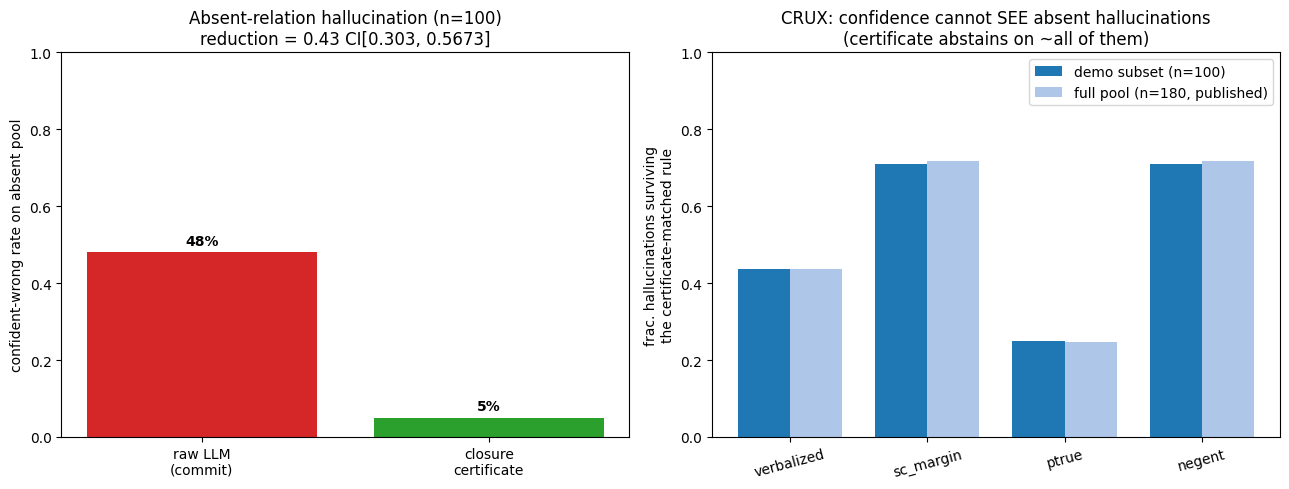

Interpretation: the closure certificate drives absent-relation confident-wrong near 0
by abstaining structurally (no derivation path). Confidence signals calibrated to the
same coverage still COMMIT ~25-72% of those same hallucinations -- they cannot tell a
confidently-invented kinship from a real one. This is the load-bearing 'certificate beats
the BEST uncertainty signal, not a strawman' evidence for the paper.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: raw hallucination vs certificate confident-wrong on the absent pool
labels1 = ["raw LLM\n(commit)", "closure\ncertificate"]
vals1 = [crux["raw_hallucination_rate_absent"], crux["certificate_confident_wrong_absent"]]
bars1 = ax1.bar(labels1, vals1, color=["#d62728", "#2ca02c"])
ax1.set_ylabel("confident-wrong rate on absent pool")
ax1.set_title(f"Absent-relation hallucination (n={len(absent)})\n"
              f"reduction = {view1['ct_verbalized']['confident_wrong_reduction']} "
              f"CI{view1['ct_verbalized']['ci95']}")
ax1.set_ylim(0, 1)
for b, val in zip(bars1, vals1):
    ax1.text(b.get_x() + b.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold")

# Panel 2: crux survival fraction per signal (demo subset vs full-pool published)
demo_surv = [crux["per_signal"][f"ct_{s}"]["frac_surviving_certificate_matched_rule"] for s in SIGNALS]
ref = data["reference_headline_full_pool"]["crux_frac_absent_hallucinations_surviving_each_signal"]
full_surv = [ref[f"ct_{s}"] for s in SIGNALS]
x = np.arange(len(SIGNALS)); w = 0.38
ax2.bar(x - w / 2, demo_surv, w, label=f"demo subset (n={len(absent)})", color="#1f77b4")
ax2.bar(x + w / 2, full_surv, w, label="full pool (n=180, published)", color="#aec7e8")
ax2.set_xticks(x); ax2.set_xticklabels(SIGNALS, rotation=15)
ax2.set_ylabel("frac. hallucinations surviving\nthe certificate-matched rule")
ax2.set_title("CRUX: confidence cannot SEE absent hallucinations\n(certificate abstains on ~all of them)")
ax2.set_ylim(0, 1); ax2.legend()
plt.tight_layout()
plt.show()

print("Interpretation: the closure certificate drives absent-relation confident-wrong near 0")
print("by abstaining structurally (no derivation path). Confidence signals calibrated to the")
print("same coverage still COMMIT ~25-72% of those same hallucinations -- they cannot tell a")
print("confidently-invented kinship from a real one. This is the load-bearing 'certificate beats")
print("the BEST uncertainty signal, not a strawman' evidence for the paper.")